In [1]:
import numpy as np
import pandas as pd
import matplotlib
import cv2
import scipy
import skimage

print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("Matplotlib:", matplotlib.__version__)
print("OpenCV:", cv2.__version__)
print("SciPy:", scipy.__version__)
print("scikit-image:", skimage.__version__)

NumPy: 2.2.6
Pandas: 2.3.3
Matplotlib: 3.10.9
OpenCV: 5.0.0
SciPy: 1.15.3
scikit-image: 0.25.2


In [2]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import ndimage as ndi
from skimage import morphology, segmentation, feature, measure

In [3]:
image_path = "BAC_18_0003_Croped.tif"

img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

print("Tamaño:", img.shape)
print("Mínimo:", img.min())
print("Máximo:", img.max())

Tamaño: (2048, 2048)
Mínimo: 0
Máximo: 255


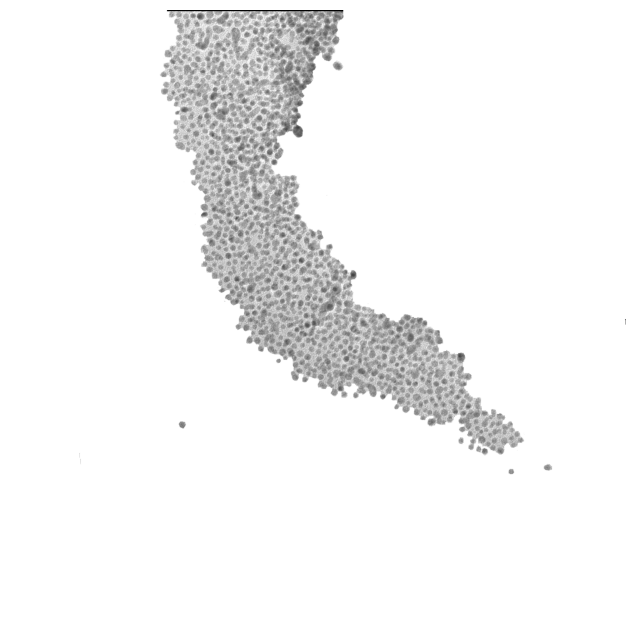

In [4]:
plt.figure(figsize=(12, 8))
plt.imshow(img, cmap="gray")
plt.axis("off");

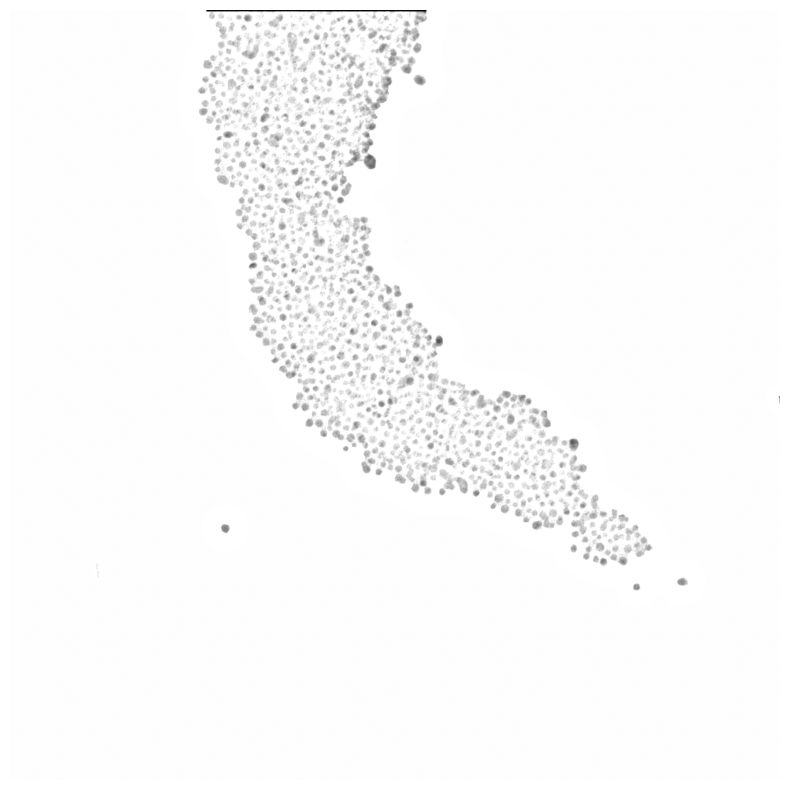

In [5]:
blur = cv2.GaussianBlur(img, (5, 5), 0)

background = cv2.GaussianBlur(
    blur,
    (0, 0),
    sigmaX=25,
    sigmaY=25
)

corrected = cv2.divide(
    blur.astype(np.float32),
    background.astype(np.float32) + 1,
    scale=255
)

corrected = np.clip(corrected, 0, 255).astype(np.uint8)

plt.figure(figsize=(10, 10))
plt.imshow(corrected, cmap="gray")
plt.axis("off");

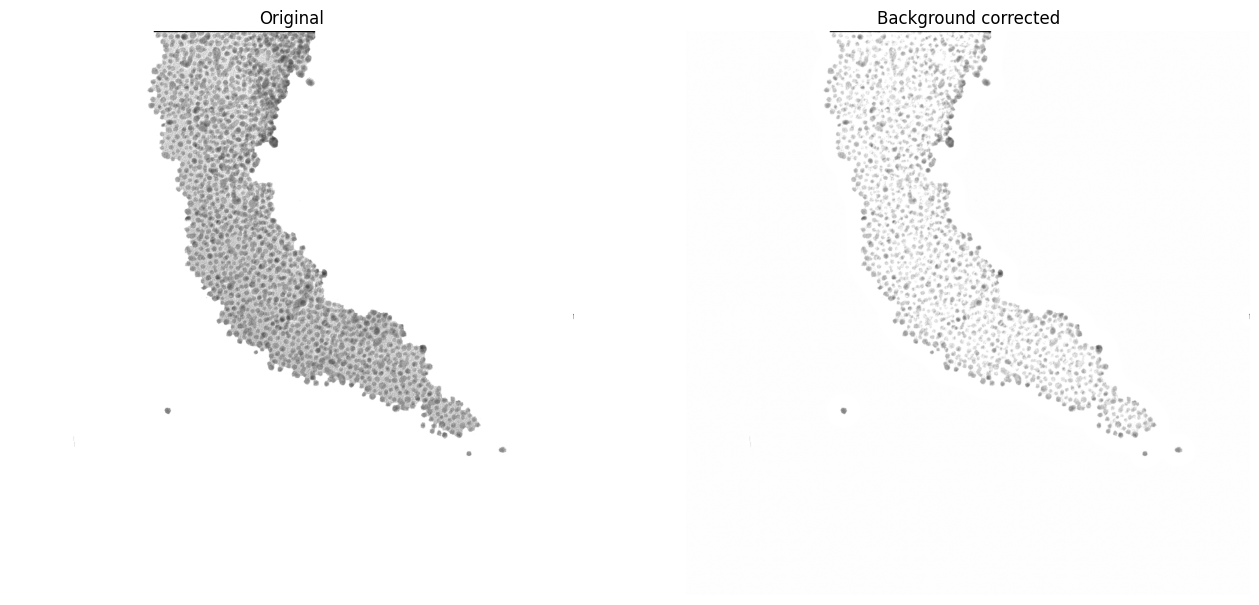

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(16, 8))

ax[0].imshow(img, cmap="gray")
ax[0].set_title("Original")
ax[0].axis("off")

ax[1].imshow(corrected, cmap="gray")
ax[1].set_title("Background corrected")
ax[1].axis("off")

plt.show()

Threshold: 224.0


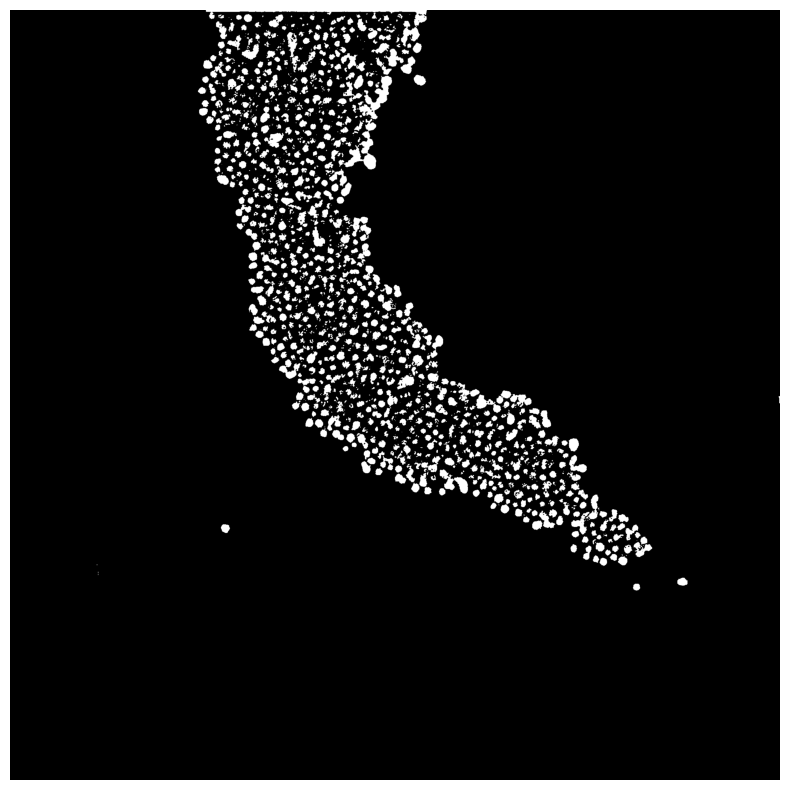

In [7]:
threshold_value, binary = cv2.threshold(
    corrected,
    0,
    255,
    cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
)

print("Threshold:", threshold_value)

plt.figure(figsize=(10,10))
plt.imshow(binary, cmap="gray")
plt.axis("off")
plt.show()

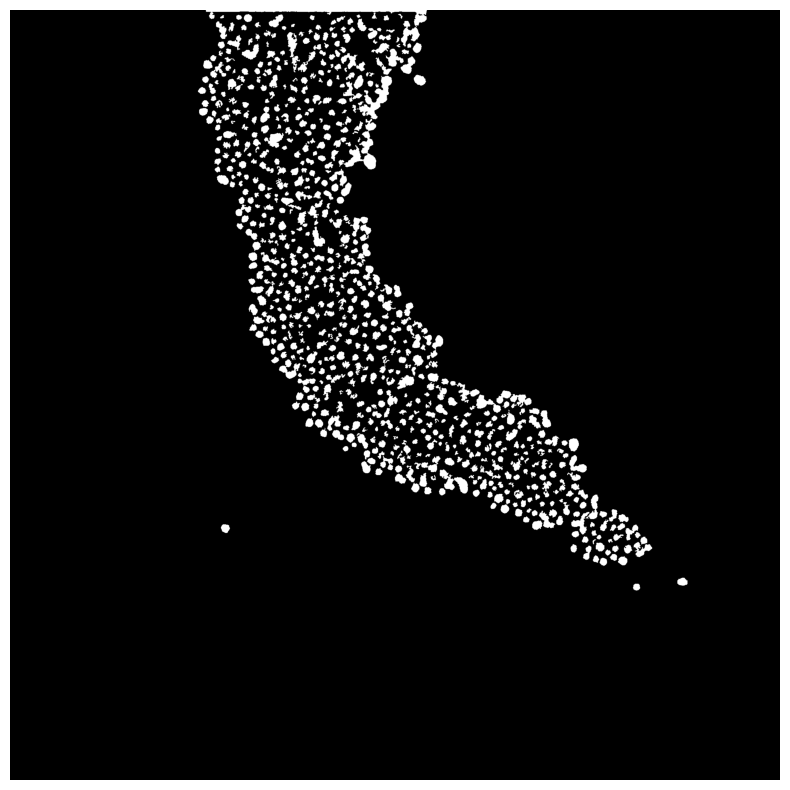

In [8]:
mask = binary > 0

mask = morphology.remove_small_objects(
    mask,
    min_size=50
)

mask = morphology.remove_small_holes(
    mask,
    area_threshold=30
)

plt.figure(figsize=(10,10))
plt.imshow(mask, cmap="gray")
plt.axis("off")
plt.show()

In [9]:
#plt.figure(figsize=(10, 5))
#
#plt.hist(
#    corrected.ravel(),
#    bins=256
#)
#
#plt.xlabel("Pixel intensity")
#plt.ylabel("Number of pixels")
#plt.title("Intensity histogram")
#
#plt.show()

In [10]:
#print("Otsu threshold:", threshold_value)

In [11]:
#thresholds = [120, 130, 140, 150, 160, 170, 180, 190]
#
#fig, axes = plt.subplots(2, 4, figsize=(16, 8))
#
#for ax, t in zip(axes.ravel(), thresholds):
#
#    test = corrected < t
#
#    ax.imshow(test, cmap="gray")
#    ax.set_title(f"Threshold = {t}")
#    ax.axis("off")
#
#plt.tight_layout()
#plt.show()

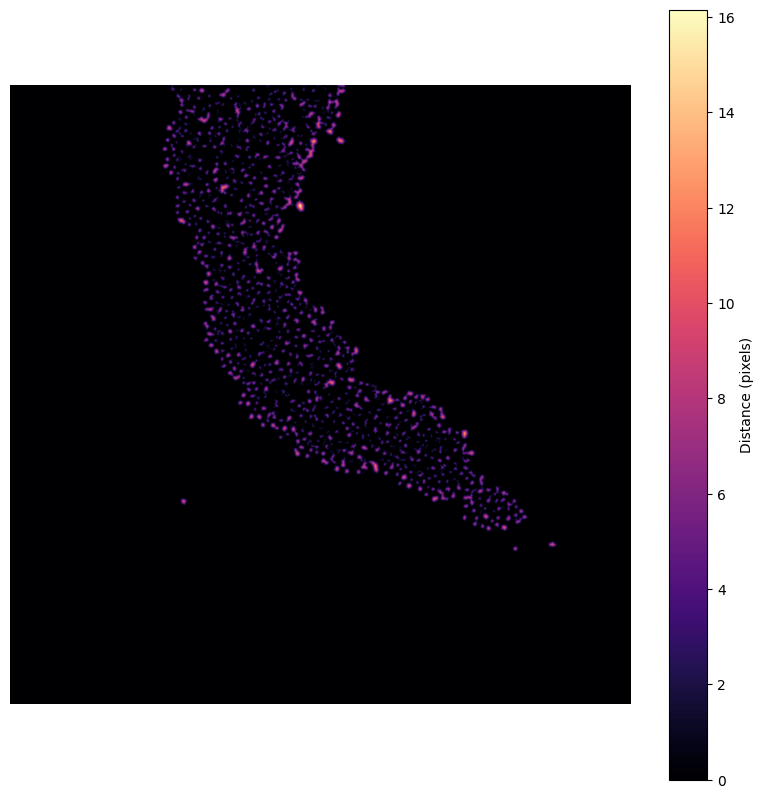

In [12]:
distance = ndi.distance_transform_edt(mask)

plt.figure(figsize=(10, 10))
plt.imshow(distance, cmap="magma")
plt.colorbar(label="Distance (pixels)")
plt.axis("off")
plt.show()

In [19]:
coordinates = feature.peak_local_max(
    distance,
    min_distance=20,
    labels=mask
)

print("Número de centros encontrados:", len(coordinates))

Número de centros encontrados: 409


In [20]:
markers = np.zeros(distance.shape, dtype=np.int32)

for i, (y, x) in enumerate(coordinates, start=1):
    markers[y, x] = i

markers = ndi.label(markers > 0)[0]

print("Markers:", markers.max())

Markers: 409


In [21]:
labels = segmentation.watershed(
    -distance,
    markers,
    mask=mask
)

print("Partículas detectadas:", labels.max())

Partículas detectadas: 409


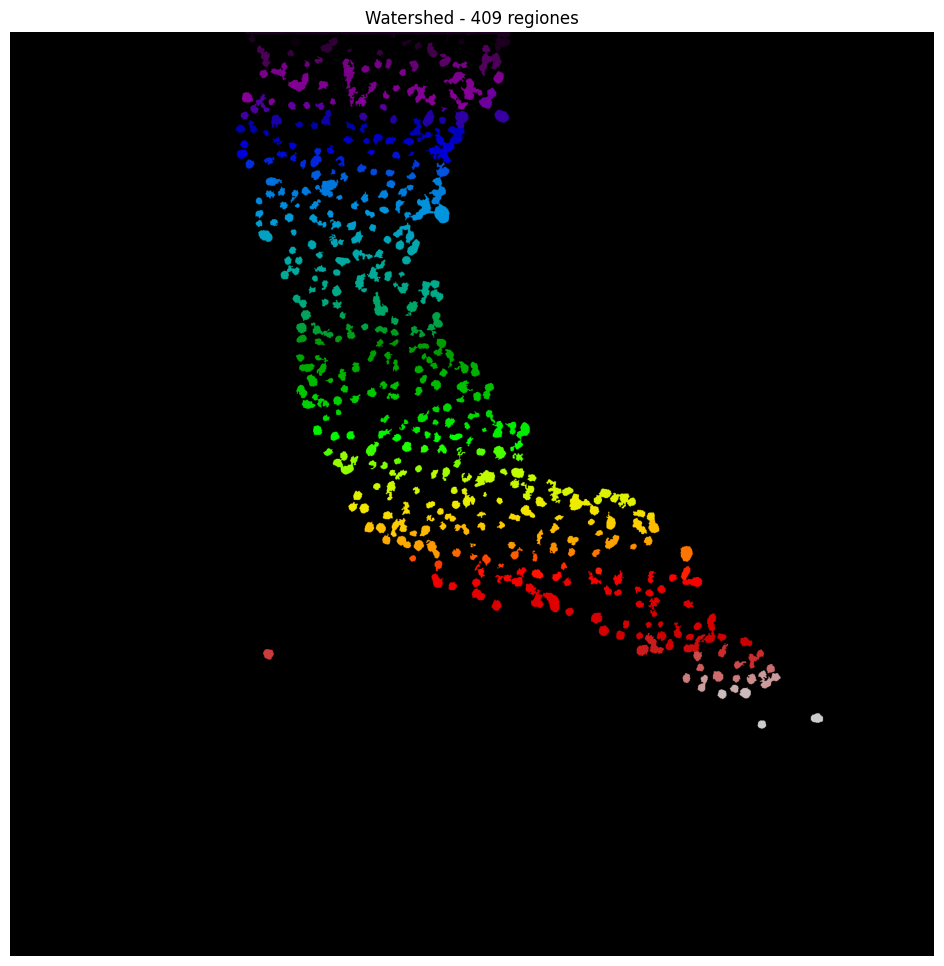

In [22]:
plt.figure(figsize=(12, 12))

plt.imshow(labels, cmap="nipy_spectral")

plt.title(f"Watershed - {labels.max()} regiones")
plt.axis("off")

plt.show()

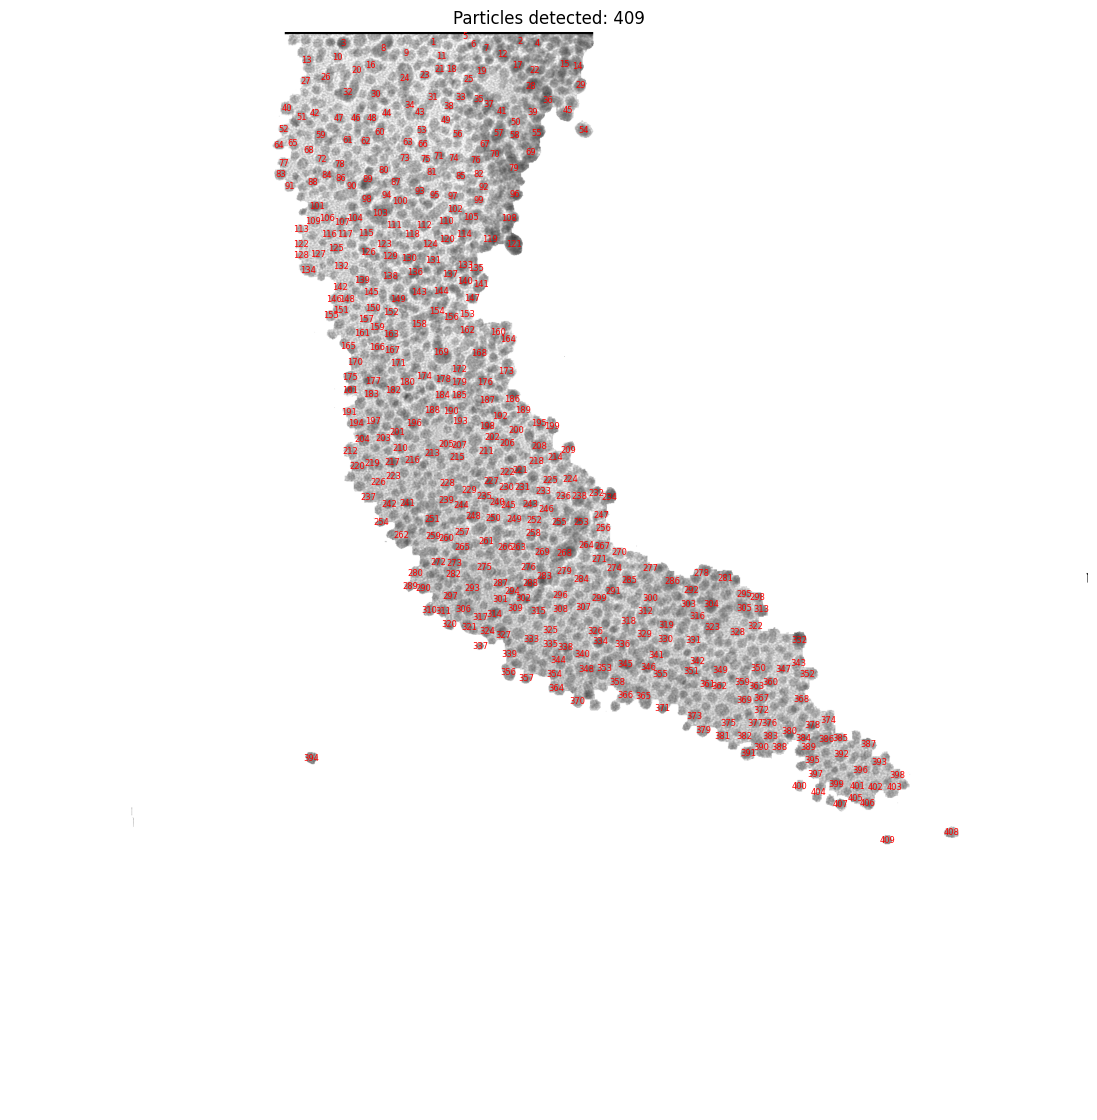

In [23]:
regions = measure.regionprops(labels)

fig, ax = plt.subplots(figsize=(14, 14))

ax.imshow(img, cmap="gray")

for region in regions:

    y, x = region.centroid

    ax.text(
        x,
        y,
        str(region.label),
        color="red",
        fontsize=6,
        ha="center",
        va="center"
    )

ax.axis("off")
ax.set_title(f"Particles detected: {len(regions)}")

plt.show()

In [24]:
regions = measure.regionprops(labels)

print("Número total de partículas:", len(regions))

Número total de partículas: 409


In [25]:
nm_per_pixel = 50 / 215

print("Escala:", nm_per_pixel, "nm/pixel")

Escala: 0.23255813953488372 nm/pixel


In [26]:
results = []

for region in regions:

    area_px = region.area

    area_nm2 = area_px * nm_per_pixel**2

    perimeter_px = region.perimeter
    perimeter_nm = perimeter_px * nm_per_pixel

    equivalent_diameter_nm = (
        region.equivalent_diameter *
        nm_per_pixel
    )

    y, x = region.centroid

    circularity = (
        4 * np.pi * area_px /
        perimeter_px**2
        if perimeter_px > 0
        else np.nan
    )

    results.append({
        "Particle": region.label,
        "Area_pixels2": area_px,
        "Area_nm2": area_nm2,
        "Equivalent_diameter_nm": equivalent_diameter_nm,
        "Perimeter_pixels": perimeter_px,
        "Perimeter_nm": perimeter_nm,
        "Circularity": circularity,
        "Centroid_X": x,
        "Centroid_Y": y
    })

df = pd.DataFrame(results)

In [27]:
df.head(845)

,Particle,Area_pixels2,Area_nm2,Equivalent_diameter_nm,Perimeter_pixels,Perimeter_nm,Circularity,Centroid_X,Centroid_Y
0,1,123.0,6.652244,2.910309,41.798990,9.720695,0.884674,803.325203,19.764228
1,2,111.0,6.003245,2.764701,51.041631,11.870147,0.535407,968.423423,16.450450
2,3,354.0,19.145484,4.937285,69.355339,16.129149,0.924812,632.497175,21.070621
3,4,145.0,7.842077,3.159880,46.384776,10.787157,0.846890,1000.255172,21.068966
4,5,3971.0,214.764738,16.536232,1418.617316,329.911004,0.024796,863.511458,6.839083
...,...,...,...,...,...,...,...,...,...
404,405,254.0,13.737155,4.182187,59.698485,13.883369,0.895606,1605.594488,1455.240157
405,406,443.0,23.958897,5.523171,79.012193,18.374929,0.891714,1629.623025,1464.679458
406,407,315.0,17.036236,4.657382,66.112698,15.375046,0.905630,1577.990476,1467.025397
407,408,450.0,24.337480,5.566636,80.870058,18.806990,0.864663,1788.084444,1520.497778


In [28]:
df_filtered = df[
    (df["Area_nm2"] >= 5) &
    (df["Area_nm2"] <= 60)
].copy()

In [29]:
print("Partículas originales:", len(df))
print("Partículas después del filtro:", len(df_filtered))

Partículas originales: 409
Partículas después del filtro: 395


In [30]:
df_filtered.head(845)

,Particle,Area_pixels2,Area_nm2,Equivalent_diameter_nm,Perimeter_pixels,Perimeter_nm,Circularity,Centroid_X,Centroid_Y
0,1,123.0,6.652244,2.910309,41.798990,9.720695,0.884674,803.325203,19.764228
1,2,111.0,6.003245,2.764701,51.041631,11.870147,0.535407,968.423423,16.450450
2,3,354.0,19.145484,4.937285,69.355339,16.129149,0.924812,632.497175,21.070621
3,4,145.0,7.842077,3.159880,46.384776,10.787157,0.846890,1000.255172,21.068966
5,6,180.0,9.734992,3.520650,67.077164,15.599341,0.502728,878.283333,23.172222
...,...,...,...,...,...,...,...,...,...
404,405,254.0,13.737155,4.182187,59.698485,13.883369,0.895606,1605.594488,1455.240157
405,406,443.0,23.958897,5.523171,79.012193,18.374929,0.891714,1629.623025,1464.679458
406,407,315.0,17.036236,4.657382,66.112698,15.375046,0.905630,1577.990476,1467.025397
407,408,450.0,24.337480,5.566636,80.870058,18.806990,0.864663,1788.084444,1520.497778


In [31]:
print("====================================")
print("     NANOPARTICLE ANALYSIS")
print("====================================")

print(f"\nTotal de partículas detectadas: {len(df)}")
print(f"Partículas después del filtro: {len(df_filtered)}")

print(
    f"Porcentaje conservado: "
    f"{100 * len(df_filtered) / len(df):.2f}%"
)

     NANOPARTICLE ANALYSIS

Total de partículas detectadas: 409
Partículas después del filtro: 395
Porcentaje conservado: 96.58%


In [32]:
area_stats = df_filtered["Area_nm2"].describe()

print(area_stats)

count    395.000000
mean      18.650382
std       10.992511
min        5.516495
25%       11.114116
50%       15.305571
75%       22.931314
max       59.707950
Name: Area_nm2, dtype: float64


In [33]:
mean_area = df_filtered["Area_nm2"].mean()
std_area = df_filtered["Area_nm2"].std()
median_area = df_filtered["Area_nm2"].median()

print(f"Área promedio  = {mean_area:.3f} nm²")
print(f"Desviación     = {std_area:.3f} nm²")
print(f"Mediana        = {median_area:.3f} nm²")
print(f"Mínimo         = {df_filtered['Area_nm2'].min():.3f} nm²")
print(f"Máximo         = {df_filtered['Area_nm2'].max():.3f} nm²")

Área promedio  = 18.650 nm²
Desviación     = 10.993 nm²
Mediana        = 15.306 nm²
Mínimo         = 5.516 nm²
Máximo         = 59.708 nm²


In [34]:
diameter = df_filtered["Equivalent_diameter_nm"]

print(f"Diámetro equivalente promedio = {diameter.mean():.3f} nm")
print(f"Desviación estándar           = {diameter.std():.3f} nm")
print(f"Mediana                       = {diameter.median():.3f} nm")
print(f"Mínimo                        = {diameter.min():.3f} nm")
print(f"Máximo                        = {diameter.max():.3f} nm")

Diámetro equivalente promedio = 4.699 nm
Desviación estándar           = 1.292 nm
Mediana                       = 4.414 nm
Mínimo                        = 2.650 nm
Máximo                        = 8.719 nm


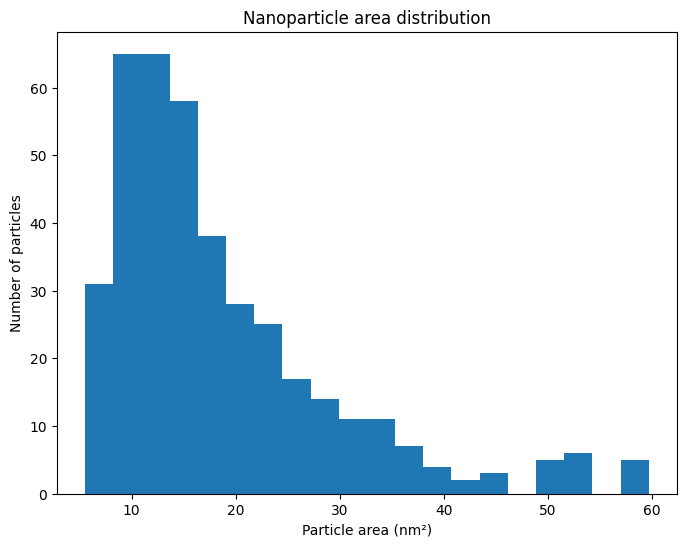

In [35]:
plt.figure(figsize=(8, 6))

plt.hist(
    df_filtered["Area_nm2"],
    bins=20
)

plt.xlabel("Particle area (nm²)")
plt.ylabel("Number of particles")
plt.title("Nanoparticle area distribution")

plt.show()

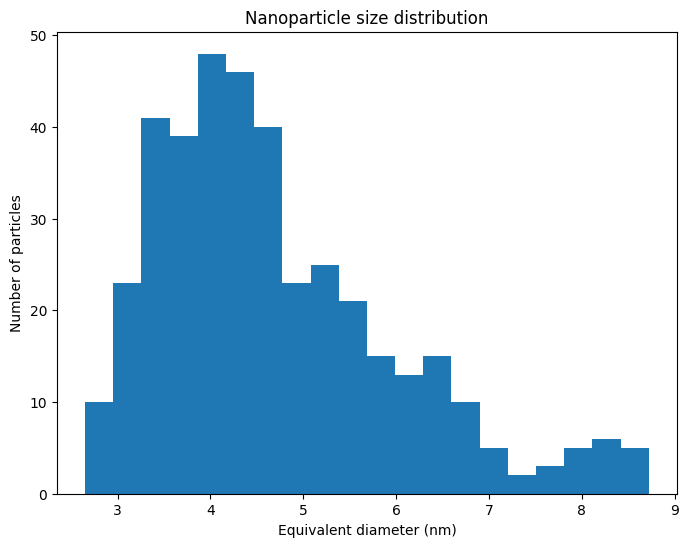

In [36]:
plt.figure(figsize=(8, 6))

plt.hist(
    df_filtered["Equivalent_diameter_nm"],
    bins=20
)

plt.xlabel("Equivalent diameter (nm)")
plt.ylabel("Number of particles")
plt.title("Nanoparticle size distribution")

plt.show()

In [37]:
areas_diametros = df_filtered[
    ["Particle", "Area_nm2", "Equivalent_diameter_nm"]
].copy()

areas_diametros.columns = [
    "Particle",
    "Area (nm²)",
    "Equivalent diameter (nm)"
]

areas_diametros.to_excel(
    "nanoparticle_areas_diameters.xlsx",
    index=False
)

print("Archivo creado correctamente.")

Archivo creado correctamente.
